Sanguinius

Início do projeto, este projeto se trata de um treinamento de uma IA para que possa avaliar as imagens de um dataset sobre tipos sanguíneos e através desta analise, identificar os diferentes tipos sanguíneo os separando entre A, B, AB e O.


---



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Realizado a importação do meu Drive pessoal onde se encontra o DataSet a ser utilizado no trabalho.

In [2]:
import os
import zipfile

zip_patch = "/content/drive/MyDrive/Colab Notebooks/Diário de Bordo/Dataset_Tipos_Sanguineos.zip"
extract_path = "/content/dataset"

# cria a pasta de destino (se não existir)
os.makedirs(extract_path, exist_ok=True)

# extrai o zip
with zipfile.ZipFile(zip_patch, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extraído com sucesso!")
print("Arquivos em:", extract_path)

Dataset extraído com sucesso!
Arquivos em: /content/dataset


Traça o caminho até o DataSet e descompacta o .zip.

In [3]:
import os
os.listdir("/content/dataset")

['ABO-BTI ABO Blood Typing', '16971046']

Listar os arquivos e pastas dentro do diretório, usado para realizar algumas verificações sobre a integridade e caminho do diretório.

In [4]:
import os

dataset_path = "/content/dataset"

for root, dirs, files in os.walk(dataset_path):
    print("Pasta:", root)
    print("Subpastas:", dirs)
    print("Quantidade de arquivos:", len(files))
    print("-"*50)

Pasta: /content/dataset
Subpastas: ['ABO-BTI ABO Blood Typing', '16971046']
Quantidade de arquivos: 0
--------------------------------------------------
Pasta: /content/dataset/ABO-BTI ABO Blood Typing
Subpastas: ['ABO-BTI_Images']
Quantidade de arquivos: 2
--------------------------------------------------
Pasta: /content/dataset/ABO-BTI ABO Blood Typing/ABO-BTI_Images
Subpastas: ['O positive', 'B positive', 'O negative', 'AB positive', 'AB negative', 'A negative', 'A positive', 'B negative']
Quantidade de arquivos: 0
--------------------------------------------------
Pasta: /content/dataset/ABO-BTI ABO Blood Typing/ABO-BTI_Images/O positive
Subpastas: []
Quantidade de arquivos: 54
--------------------------------------------------
Pasta: /content/dataset/ABO-BTI ABO Blood Typing/ABO-BTI_Images/B positive
Subpastas: []
Quantidade de arquivos: 54
--------------------------------------------------
Pasta: /content/dataset/ABO-BTI ABO Blood Typing/ABO-BTI_Images/O negative
Subpastas: []
Q

Exibe todas as pastas e arquivos encontrados no dataset.\
Com o código abaixo, busca todas as imagens contidas na pasta e exibe as primeiras 6 que serão expostas a título de exemplo para apresentações e explicações.

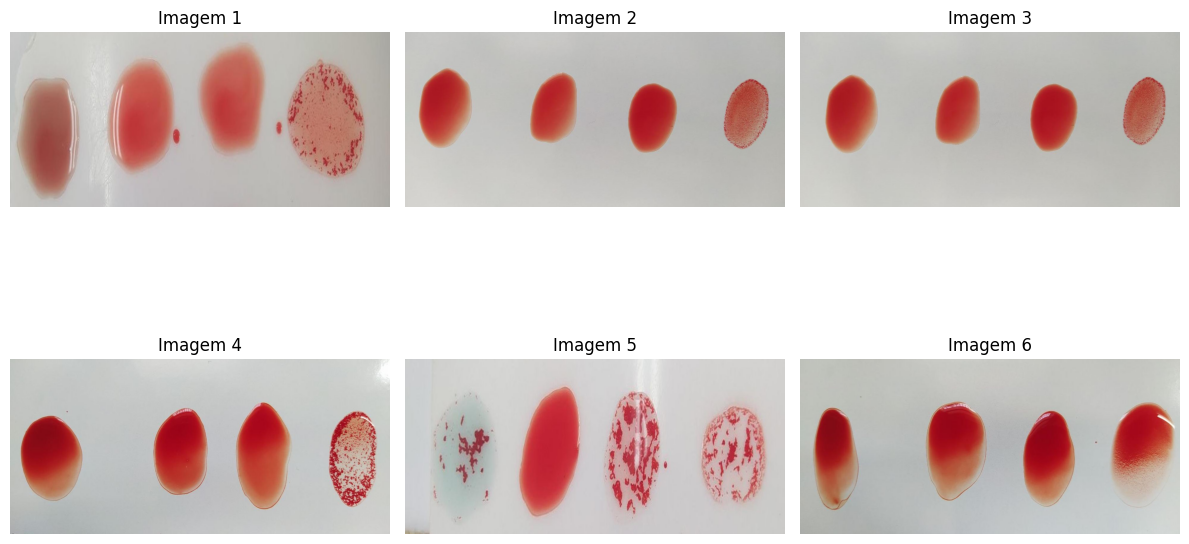

In [5]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

dataset_path = "/content/dataset"

# Lista para guardar caminhos das imagens
imagens = []

# Procura imagens no dataset
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            imagens.append(os.path.join(root, file))

# Mostrar as primeiras 6 imagens
plt.figure(figsize=(12,8))

for i in range(6):
    img = mpimg.imread(imagens[i])

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"Imagem {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Criando Gerador de Imagens\
*(será coletado as imagens da pasta, associado automaticamente cada pasta a uma classe e cria dois conjuntos sendo um o treino para a Ia e outro para a validação dos testes de aprendizado)*

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

dataset_path = "/content/dataset/ABO-BTI ABO Blood Typing/ABO-BTI_Images"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 352 images belonging to 8 classes.
Found 80 images belonging to 8 classes.


Criando o modelo e construindo a Rede Neural

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [8]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(8, activation='softmax')  # 8 classes de sangue
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,992 (42.61 MB)

 Trainable params: 11,169,992 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Compilar o modelo


In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
loss='sparse_categorical_crossentropy'

Treinamento do modelo (fit)\
Explicando de forma simples

Quando você chama fit, você está dizendo para a rede neural:

1. Olhe os dados de treino
2. Faça uma previsão
3. Compare com a resposta correta
4. Calcule o erro (loss)
5. Ajuste os pesos internos
6. Repita isso várias vezes



In [13]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

loss, accuracy = model.evaluate(val_data)

print("Loss:", loss)
print("Accuracy:", accuracy)

Epoch 1/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 58s 5s/step - accuracy: 0.2699 - loss: 2.2832 - val_accuracy: 0.5625 - val_loss: 1.5912
Epoch 2/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.6591 - loss: 1.0324 - val_accuracy: 0.8125 - val_loss: 0.5316
Epoch 3/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.8864 - loss: 0.3887 - val_accuracy: 1.0000 - val_loss: 0.1150
Epoch 4/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 43s 4s/step - accuracy: 0.9631 - loss: 0.1371 - val_accuracy: 1.0000 - val_loss: 0.0108
Epoch 5/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.9659 - loss: 0.0940 - val_accuracy: 0.9625 - val_loss: 0.1210
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 689ms/step - accuracy: 0.9625 - loss: 0.1210
Loss: 0.12095091491937637
Accuracy: 0.9624999761581421


In [14]:
import json

with open("/content/drive/MyDrive/Colab Notebooks/Diário de Bordo/modelos/classes.json", "w") as f:
    json.dump(train_data.class_indices, f)

Salve o mapeamento de classes junto do modelo

In [15]:
model.save("/content/drive/MyDrive/Colab Notebooks/Diário de Bordo/modelos/modelo.keras")

Salvar o Dataset

Analise
Após construção, treinamento e teste, é possível notar que o dataset apresenta um aprendizado rápido e preciso com relação ás imagens usadas, tendo como objetivo identificar e classificar os tipos sanguíneos atraves de testes, sendo eles divididos entre A, B, AB ou O. Obtivemos uma acurácia bem próxima de 100% com o passar das épocas, cumprindo com as espectativas que são uma acurácia maior conforme o avançar das épocas, tendo então, sucesso nestes treinamentos, estando apto para a próxima etapa que é a pratica real utilizando imagens originárias do Dataset que foram removidas antes da fase de aprendizado da IA.